# Experiment 2 Tree-Search Agent

这个 notebook 整理当前实验2 agent 的算法、参数和行为可视化。

当前版本的 agent 具有以下机制：

1. 以整张地图的颜色状态作为搜索树节点
2. 以一次合法改色动作作为状态转移
3. 先围绕冲突区域按图距离生成候选动作
4. 用启发式规则对动作做剪枝：
   - 改完后冲突边更少的优先
   - 如果并列，改完后下一步冲突区本身可改的优先
5. 保留并增量扩展搜索树，而不是每一步从头搜索
6. 每一步内部进行若干轮 `select -> expand -> backpropagate`
7. 用 `best_child` 作为当前应执行的动作
8. 同分时优先访问次数更少的节点/分支

当前默认关键参数：

- `max_depth = 4`
- `n_iterations = 20`
- `random_tie_break = False`

在这组参数下，agent 当前可以解开全部 10 轮材料。

In [1]:
from pathlib import Path
import math
import sys
import importlib

analysis_dir = Path.cwd()
if not (analysis_dir / "conflict_search_agent.py").exists():
    analysis_dir = Path.cwd() / "model code" / "experiment2" / "analysis_code"
if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

import conflict_search_agent as agent
import visualize_conflict_search_agent as viz

agent = importlib.reload(agent)
viz = importlib.reload(viz)


def configure_chinese_font():
    available = {f.name for f in font_manager.fontManager.ttflist}
    candidates = [
        "Source Han Sans SC",
        "Hiragino Sans GB",
        "Songti SC",
        "Arial Unicode MS",
    ]
    chosen = next((name for name in candidates if name in available), "DejaVu Sans")
    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = [chosen, "DejaVu Sans", "Arial Unicode MS"]
    mpl.rcParams["axes.unicode_minus"] = False
    return chosen


plt.style.use("default")
font_name = configure_chinese_font()
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
print(f"当前使用字体: {font_name}")

当前使用字体: Source Han Sans SC


In [2]:
MAX_DEPTH = 4
N_ITERATIONS = 20
RANDOM_TIE_BREAK = False

materials = agent.load_materials()
round_summary_df, step_trace_df = agent.run_tree_agent_on_all_rounds(
    max_depth=MAX_DEPTH,
    n_iterations=N_ITERATIONS,
    random_tie_break=RANDOM_TIE_BREAK,
)
round_summary_df

,round,condition_type,initial_conflict_edges,final_conflict_edges,n_agent_steps,solved,max_depth,n_iterations,random_tie_break,random_seed
0,1,requires_nonconflict_region,11,0,6,True,4,20,False,None
1,2,requires_nonconflict_region,4,0,4,True,4,20,False,None
2,3,requires_nonconflict_region,6,0,4,True,4,20,False,None
3,4,requires_nonconflict_region,4,0,4,True,4,20,False,None
4,5,requires_nonconflict_region,3,0,6,True,4,20,False,None
5,6,requires_adjacent_nonconflict_pair,8,0,12,True,4,20,False,None
6,7,requires_adjacent_nonconflict_pair,6,0,5,True,4,20,False,None
7,8,requires_adjacent_nonconflict_pair,5,0,6,True,4,20,False,None
8,9,requires_adjacent_nonconflict_pair,8,0,6,True,4,20,False,None
9,10,requires_adjacent_nonconflict_pair,7,0,7,True,4,20,False,None


## 每轮结果汇总

下面先看每轮是否解开、用了多少步。

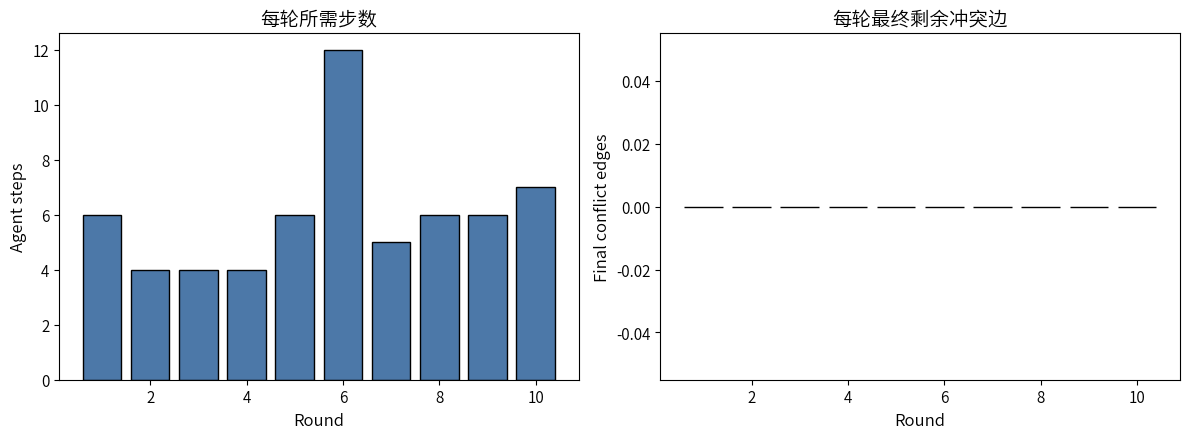

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(round_summary_df["round"], round_summary_df["n_agent_steps"], color="#4c78a8", edgecolor="black")
axes[0].set_xlabel("Round", fontsize=12)
axes[0].set_ylabel("Agent steps", fontsize=12)
axes[0].set_title("每轮所需步数", fontsize=14)

axes[1].bar(
    round_summary_df["round"],
    round_summary_df["final_conflict_edges"],
    color="#f58518",
    edgecolor="black",
)
axes[1].set_xlabel("Round", fontsize=12)
axes[1].set_ylabel("Final conflict edges", fontsize=12)
axes[1].set_title("每轮最终剩余冲突边", fontsize=14)

for ax in axes:
    ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

## 关键变量说明

- `search_depth`：当前动作对应 region 离冲突区有多少层
- `planning_depth_used`：树搜索允许向下看的最大深度
- `tree_iterations_used`：每一步内部做了多少轮 `select -> expand -> backpropagate`
- `expanded_root_children`：当前 root 下实际建出来的 child 数
- `selected_found_solution_within_depth`：在当前深度视野内，是否已经找到了完整解路径

In [4]:
step_trace_df.head(20)

,round,condition_type,agent_step,terminated,reason,search_depth,region,old_color,new_color,n_conflict_edges_before,n_conflict_edges_after,conflict_delta,conflict_regions_before,selected_found_solution_within_depth,planning_depth_used,tree_iterations_used,expanded_root_children,improved_conflicts
0,1,requires_nonconflict_region,0,False,,0,12,3,1,11,7,-4,3 7 8 12 13 15 20 26 30 31 32 34 44,False,4,20,2,True
1,1,requires_nonconflict_region,1,False,,0,2,3,2,7,5,-2,3 7 8 12 15 26 30 31 32 34 44,False,4,20,4,True
2,1,requires_nonconflict_region,2,False,,0,25,3,0,5,3,-2,8 12 26 30 31 32 34 44,True,4,20,3,True
3,1,requires_nonconflict_region,3,False,,0,33,2,0,3,1,-2,12 30 32 34 44,True,4,20,1,True
4,1,requires_nonconflict_region,4,False,,1,23,3,2,1,1,0,32 44,True,4,20,1,False
5,1,requires_nonconflict_region,5,False,,0,31,0,3,1,0,-1,32 44,True,4,20,2,True
6,2,requires_nonconflict_region,0,False,,0,26,2,0,4,2,-2,5 21 22 27 30 44,True,4,20,1,True
7,2,requires_nonconflict_region,1,False,,0,43,0,1,2,1,-1,21 22 30 44,True,4,20,2,True
8,2,requires_nonconflict_region,2,False,,1,14,3,1,1,1,0,21 22,True,4,20,3,False
9,2,requires_nonconflict_region,3,False,,0,20,2,3,1,0,-1,21 22,True,4,20,1,True


## 按 round 查看整轮动作拼图

下面这个函数会把某一轮的所有动作画在一张图里：

- 每个 subplot 是该步动作执行前的地图状态
- 黑框是当前 agent 选中的 region
- 红边是当前冲突区域
- 标题里会显示 step、region、颜色变化和冲突边变化
- 每行固定放 3 个动作

只需要改 `ROUND_TO_PLOT`，重新运行下面两格，就能生成另一轮的图。

In [5]:
def plot_round_action_gallery(
    round_index: int,
    max_depth: int = MAX_DEPTH,
    n_iterations: int = N_ITERATIONS,
    random_tie_break: bool = RANDOM_TIE_BREAK,
    max_steps: int = 200,
    ncols: int = 3,
):
    round_data = materials["rounds"][round_index - 1]
    trace = agent.trace_tree_agent_on_round(
        round_data,
        max_steps=max_steps,
        max_depth=max_depth,
        n_iterations=n_iterations,
        random_tie_break=random_tie_break,
    )
    action_trace = [step for step in trace if step["status"] == "action"]
    if not action_trace:
        raise ValueError(f"Round {round_index} 没有可绘制的动作。")

    grid = round_data["mapData"]["grid"]
    region_cells = viz.build_region_cells(grid)
    border_segments = viz.build_border_segments(grid)

    nrows = math.ceil(len(action_trace) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5.0 * nrows))
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    for ax in axes.flat:
        ax.axis("off")

    for idx, step in enumerate(action_trace):
        ax = axes[idx // ncols, idx % ncols]
        viz.render_state(
            ax,
            grid,
            step["colors_before"],
            border_segments,
            region_cells,
            step["conflict_edges_before"],
            selected_region=step["region"],
        )
        ax.set_title(
            f"Step {step['agent_step']} | R{step['region'] + 1} "
            f"C{step['old_color'] + 1}->{step['new_color'] + 1}\n"
            f"conflicts {len(step['conflict_edges_before'])}->{len(step['conflict_edges_after'])}",
            fontsize=11,
            pad=8,
        )

    fig.suptitle(
        f"Round {round_index} 动作拼图 | max_depth={max_depth} | n_iterations={n_iterations}",
        fontsize=18,
        y=0.995,
    )
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()

    return trace

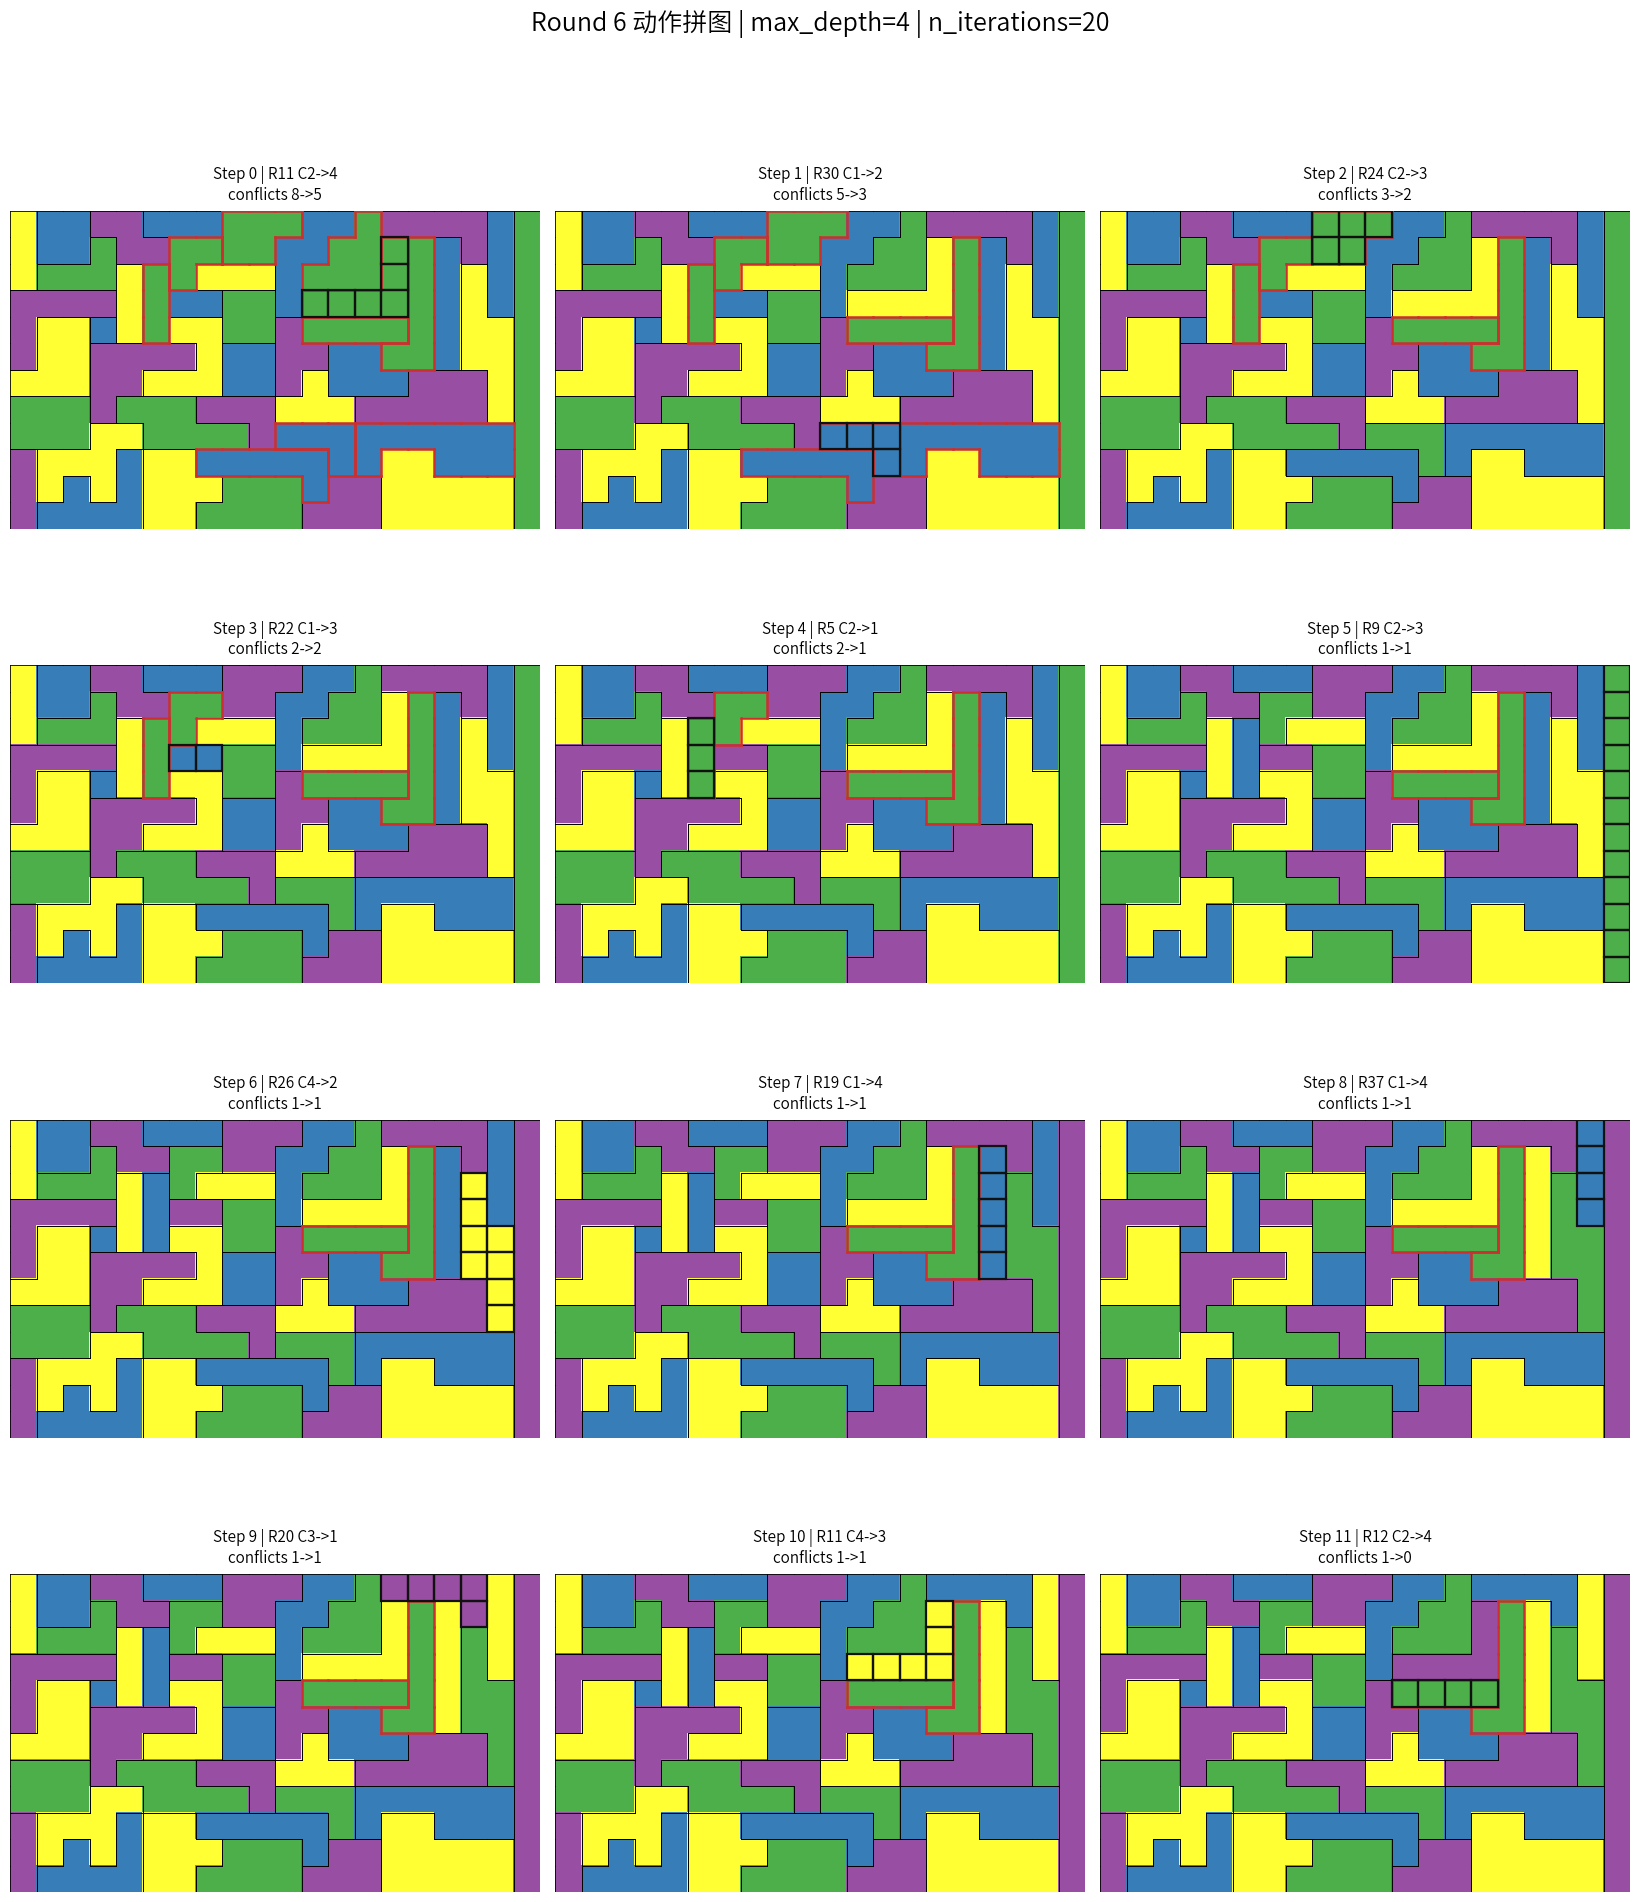

In [6]:
ROUND_TO_PLOT = 6
round_trace = plot_round_action_gallery(ROUND_TO_PLOT)

## 查看某一轮的详细动作表

如果想逐步看这一轮的决策变量，可以直接看 `round_trace`。

In [7]:
pd.DataFrame(
    [
        {
            "agent_step": step["agent_step"],
            "search_depth": step["search_depth"],
            "region": step["region"] + 1,
            "old_color": step["old_color"] + 1,
            "new_color": step["new_color"] + 1,
            "conflicts_before": len(step["conflict_edges_before"]),
            "conflicts_after": len(step["conflict_edges_after"]),
            "selected_score": step["selected_score"],
            "selected_found_solution_within_depth": step["selected_found_solution_within_depth"],
        }
        for step in round_trace
        if step["status"] == "action"
    ]
)

,agent_step,search_depth,region,old_color,new_color,conflicts_before,conflicts_after,selected_score,selected_found_solution_within_depth
0,0,0,11,2,4,8,5,"(0, -2, 1, 0, 0)",False
1,1,0,30,1,2,5,3,"(0, -1, 0, -3, 0)",False
2,2,0,24,2,3,3,2,"(0, -1, 0, -2, 0)",False
3,3,1,22,1,3,2,2,"(0, -1, 0, -1, 0)",False
4,4,0,5,2,1,2,1,"(0, -1, 0, -1, 0)",False
5,5,3,9,2,3,1,1,"(0, -1, 0, -1, 0)",False
6,6,2,26,4,2,1,1,"(0, -1, 0, -1, 0)",False
7,7,1,19,1,4,1,1,"(0, -1, 0, -1, 0)",False
8,8,2,37,1,4,1,1,"(1, 0, 1, 0, 0)",True
9,9,1,20,3,1,1,1,"(1, 0, 1, 0, 0)",True


In [ ]:
results_dir = analysis_dir.parent / "results"
results_dir.mkdir(parents=True, exist_ok=True)

round_out = results_dir / "conflict_search_tree_agent_round_summary.csv"
step_out = results_dir / "conflict_search_tree_agent_step_trace.csv"

round_summary_df.to_csv(round_out, index=False, encoding="utf-8-sig")
step_trace_df.to_csv(step_out, index=False, encoding="utf-8-sig")

print(round_out)
print(step_out)